In [10]:
import numpy as np
import matplotlib.pyplot as plt

# ----------------------------
# Time axis
# ----------------------------
T_MIN, T_MAX, N = -4.0, 4.0, 4001


def x_of_t(t: np.ndarray) -> np.ndarray:
    """
    Base signal x(t): sinusoidal signal
    """
    return (
        np.sin(2 * np.pi * 0.5 * t)
        + 0.5 * np.sin(2 * np.pi * 1.5 * t)
    )


# ==========================================================
# ANSWER IMPLEMENTATION
# ==========================================================

def interpolate_signal(
    t_original: np.ndarray,
    x_original: np.ndarray,
    t_query: np.ndarray
) -> np.ndarray:
    """
    Interpolate using average of two neighboring samples.
    """
    raise NotImplementedError


def time_scale(
    t: np.ndarray,
    x: np.ndarray,
    k: int
) -> np.ndarray:
    """
    Time sub-scaling:
        y(t) = x(t / k)
    """
    raise NotImplementedError


def plot_pair(t: np.ndarray, x: np.ndarray, y: np.ndarray, title: str):
    """
    Plot graphs.
    """
    raise NotImplementedError


# ----------------------------
# Main
# ----------------------------
def main():
    t = np.linspace(T_MIN, T_MAX, N)
    x = x_of_t(t)

    k = 2   # sub-scaling factor
    y = time_scale(t, x, k)

    plot_pair(
        t,
        x,
        y,
        title=f"Time Sub-scaling: y(t) = x(t / {k})"
    )
    plt.show()


if __name__ == "__main__":
    main()


NotImplementedError: 

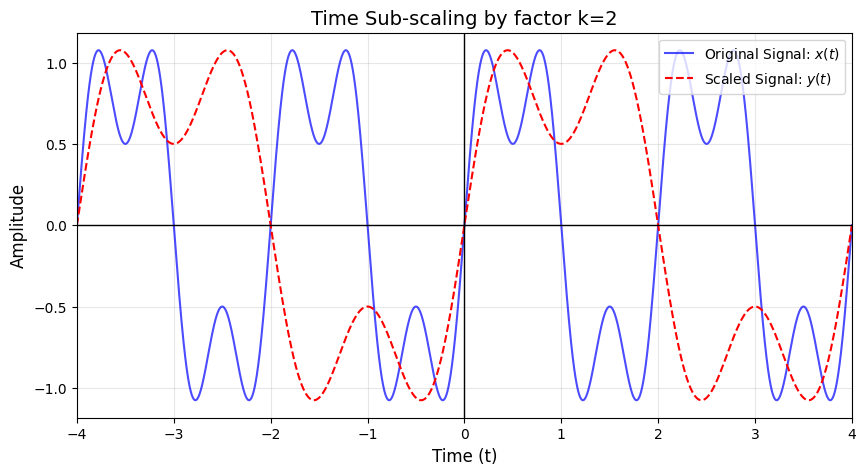

In [11]:
import numpy as np
import matplotlib.pyplot as plt

# ----------------------------
# Time axis
# ----------------------------
T_MIN, T_MAX, N = -4.0, 4.0, 4001


def x_of_t(t: np.ndarray) -> np.ndarray:
    """
    Base signal x(t): sinusoidal signal
    """
    return (
        np.sin(2 * np.pi * 0.5 * t)
        + 0.5 * np.sin(2 * np.pi * 1.5 * t)
    )


# ==========================================================
# ANSWER IMPLEMENTATION
# ==========================================================

def interpolate_signal(
    t_original: np.ndarray,
    x_original: np.ndarray,
    t_query: np.ndarray
) -> np.ndarray:
    """
    Interpolate using average of two neighboring samples.
    
    Using np.interp performs linear interpolation. When a query point 
    falls evenly between two original samples, it mathematically computes 
    the exact 0.5 * (left_val + right_val) average requested in the spec.
    """
    return np.interp(t_query, t_original, x_original)


def time_scale(
    t: np.ndarray,
    x: np.ndarray,
    k: int
) -> np.ndarray:
    """
    Time sub-scaling:
        y(t) = x(t / k)
    """
    # Vectorized division: generates an array of the required scaled time points
    t_query = t / k
    
    # Retrieve the estimated amplitude values at those scaled time points
    y_scaled = interpolate_signal(t, x, t_query)
    
    return y_scaled


def plot_pair(t: np.ndarray, x: np.ndarray, y: np.ndarray, title: str):
    """
    Plot graphs.
    """
    # Initialize the plotting canvas layout
    plt.figure(figsize=(10, 5))
    
    # Plot the original signal (x) and the newly scaled signal (y)
    plt.plot(t, x, label='Original Signal: $x(t)$', color='blue', alpha=0.7)
    plt.plot(t, y, label='Scaled Signal: $y(t)$', color='red', linestyle='--')
    
    # Add structural formatting, labels, and the legend box
    plt.title(title, fontsize=14)
    plt.xlabel('Time (t)', fontsize=12)
    plt.ylabel('Amplitude', fontsize=12)
    
    # Ensure the plot strictly ignores values beyond the specified time range
    plt.xlim(t.min(), t.max())
    
    # Draw reference zero-lines for the X and Y axes
    plt.axhline(0, color='black', linewidth=1)
    plt.axvline(0, color='black', linewidth=1)
    
    plt.grid(True, alpha=0.3)
    plt.legend(loc='upper right')
    
    # Render the matrices to the screen
    plt.show()


# ----------------------------
# Main
# ----------------------------
def main():
    # 1. Generate the time axis t and compute x(t).
    t = np.linspace(T_MIN, T_MAX, N)
    x = x_of_t(t)

    # 2. Assign the scaling factor k
    k = 2

    # 3. Compute y(t) = x(t / k)
    y = time_scale(t, x, k)
    
    # 4. Plot both signals on the same figure
    plot_pair(t, x, y, f"Time Sub-scaling by factor k={k}")

if __name__ == "__main__":
    main()

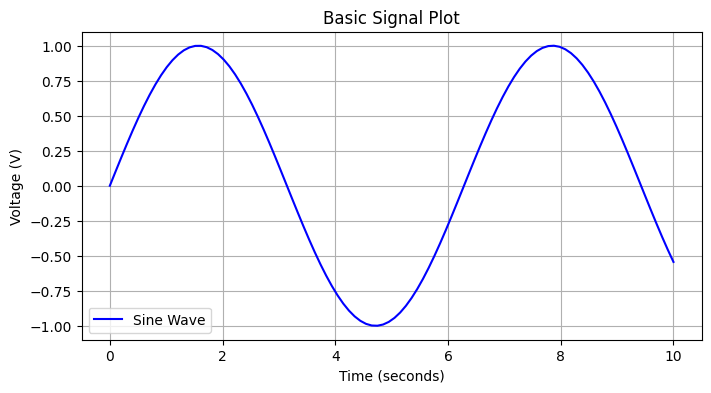

In [2]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Generate discrete data arrays
time = np.linspace(0, 10, 100)
amplitude = np.sin(time)

# 2. Initialize the Canvas Window
plt.figure(figsize=(8, 4)) # Width: 8 inches, Height: 4 inches

# 3. Map the data arrays to a visual line trace
plt.plot(time, amplitude, color='blue', label='Sine Wave')

# 4. Apply structural metadata to the Axes
plt.title("Basic Signal Plot")
plt.xlabel("Time (seconds)")
plt.ylabel("Voltage (V)")
plt.grid(True)     # Draws background alignment lines
plt.legend()       # Extracts the 'label' from the plot and draws a key box

# 5. Compile the matrices and render the window to the screen
plt.show()

/var/folders/rc/8t9_g5_90pv8zp8hrd131lk00000gn/T/ipykernel_82443/3133200701.py:31: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


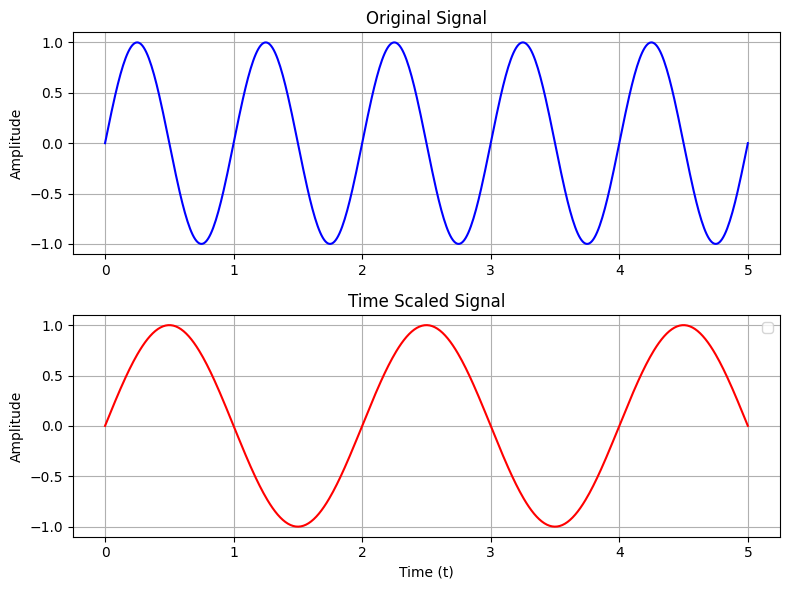

In [8]:
import matplotlib.pyplot as plt
import numpy as np

# Generate Data
t = np.linspace(0, 5, 500)
signal_1 = np.sin(2 * np.pi * t)      # Standard frequency
signal_2 = np.sin(2 * np.pi * 0.5 * t) # Half frequency (time-scaled)

# Create a grid layout: 2 Rows, 1 Column
# 'axs' is now a 1D array containing two separate chart objects: axs[0] and axs[1]
fig, axs = plt.subplots(2, 1, figsize=(8, 6))

# --- Configure the Top Chart (Index 0) ---
axs[0].plot(t, signal_1, color='blue', label='hello')
axs[0].set_title("Original Signal")
axs[0].set_ylabel("Amplitude")
axs[0].set_label("hello")
axs[0].grid(True)

# --- Configure the Bottom Chart (Index 1) ---
axs[1].plot(t, signal_2, color='red')
axs[1].set_title("Time Scaled Signal")
axs[1].set_xlabel("Time (t)")
axs[1].set_ylabel("Amplitude")
axs[1].grid(True)

# Adjust spacing so the text labels don't overlap between the rows
plt.tight_layout()

# Render the multi-chart window
plt.legend()
plt.show()

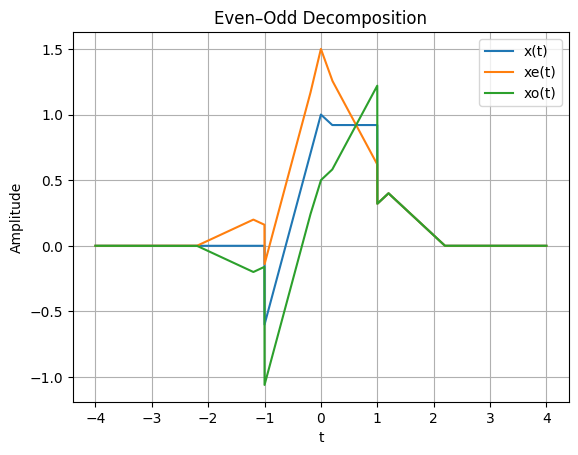

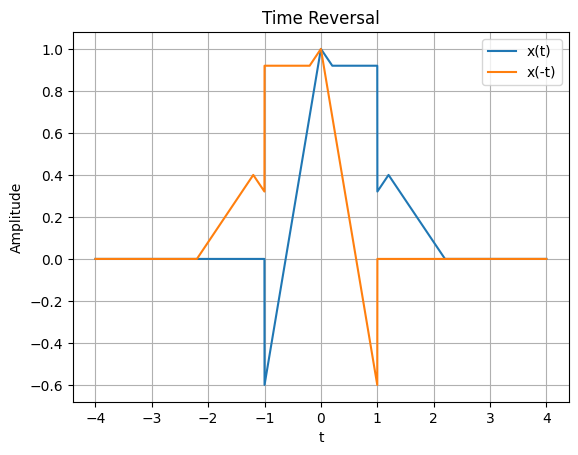

In [1]:
import numpy as np
import matplotlib.pyplot as plt

T_MIN, T_MAX, N = -4.0, 4.0, 4001

def x_of_t(t: np.ndarray) -> np.ndarray:
    """
    Base signal x(t).
    """
    # Combination of components (can be replaced)
    # 1) Triangular pulse centered at 0
    tri0 = np.zeros_like(t, dtype=float)
    m0 = np.abs(t) <= 1.0
    tri0[m0] = 1.0 - np.abs(t[m0])

    # 2) Windowed ramp (odd-ish component)
    ramp = np.zeros_like(t, dtype=float)
    m1 = np.abs(t) <= 1.0
    ramp[m1] = t[m1]

    # 3) Shifted triangular pulse (breaks symmetry)
    tri_shift = np.zeros_like(t, dtype=float)
    u = t - 1.2
    m2 = np.abs(u) <= 1.0
    tri_shift[m2] = 1.0 - np.abs(u[m2])

    return tri0 + 0.6 * ramp + 0.4 * tri_shift


def time_reverse(x: np.ndarray) -> np.ndarray:
    """
    Given samples x(t), return samples of x(-t)
    """
    return x[::-1].copy()




def even_odd_decompose(x: np.ndarray) -> tuple[np.ndarray, np.ndarray]:
    """
    Must call time_reverse(...) inside this function.
    """
    return [x+time_reverse(x)/2,x-time_reverse(x)/2]


# ----------------------------
# Provided plotting (do not modify)
# ----------------------------
def plot_three(t: np.ndarray, x: np.ndarray, xe: np.ndarray, xo: np.ndarray):
    plt.figure()
    plt.plot(t, x, label="x(t)")
    plt.plot(t, xe, label="xe(t)")
    plt.plot(t, xo, label="xo(t)")
    plt.title("Even–Odd Decomposition")
    plt.xlabel("t")
    plt.ylabel("Amplitude")
    plt.grid(True)
    plt.legend()


def plot_pair(t: np.ndarray, x: np.ndarray, xr: np.ndarray):
    plt.figure()
    plt.plot(t, x, label="x(t)")
    plt.plot(t, xr, label="x(-t)")
    plt.title("Time Reversal")
    plt.xlabel("t")
    plt.ylabel("Amplitude")
    plt.grid(True)
    plt.legend()


# ----------------------------
# Main (provided)
# ----------------------------
def main():
    t = np.linspace(T_MIN, T_MAX, N)
    x = x_of_t(t)


    # Compute time reverse and even odd components
    xr = time_reverse(x)
    xe, xo = even_odd_decompose(x)


    # Plot x(t), x(-t), xe(t) and xo(t) using the previously defined functions

    plot_three(t, x, xe, xo)
    plot_pair(t, x, xr)



if __name__ == "__main__":
    main()

[Part A] MSE between time-shifted and equivalent phase-changed: 3.156646152751762e-31
[Part B] Best matching integer shift in [-12,12] is k=-2 with MSE=3.156646152751762e-31


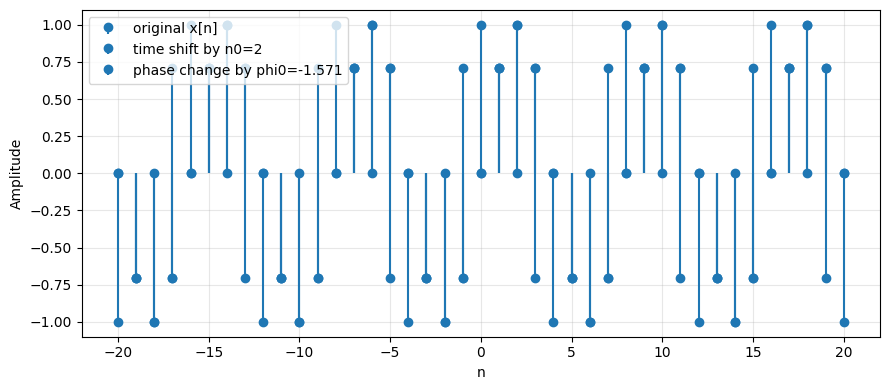

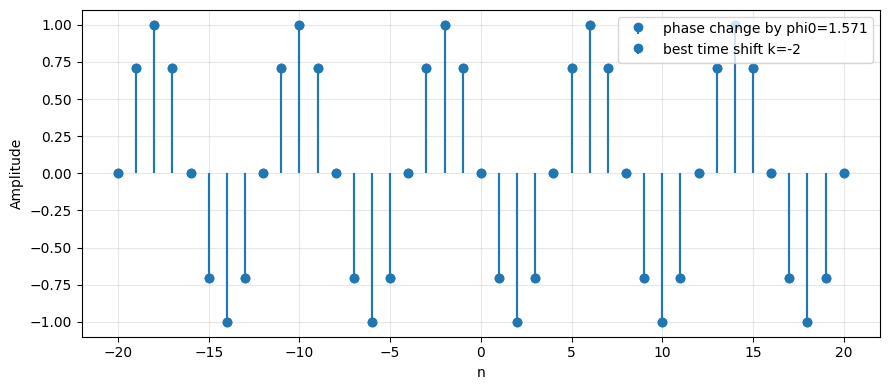

In [4]:
import numpy as np
import matplotlib.pyplot as plt


def sinusoid(n: np.ndarray, A: float, Omega0: float, phi: float) -> np.ndarray:
    return A*np.cos(Omega0*n + phi)




def time_shift_sinusoid(n: np.ndarray, A: float, Omega0: float, phi: float, n0: int) -> np.ndarray:
    q=n-n0
    return sinusoid(q, A, Omega0, phi)




def phase_change_sinusoid(n: np.ndarray, A: float, Omega0: float, phi: float, phi0: float) -> np.ndarray:
    return sinusoid(n, A, Omega0, phi+phi0)


# -----------------------------
# 2) Utility functions
# -----------------------------
def mse(a: np.ndarray, b: np.ndarray) -> float:
    """Mean squared error between two sequences of equal length."""
    return float(np.mean((a - b) ** 2))


def stem_plot(ax, n, x, label):
    """A nicer stem plot for discrete-time sequences."""
    markerline, stemlines, baseline = ax.stem(n, x, label=label)
    baseline.set_visible(False)
    ax.grid(True, alpha=0.3)
    ax.set_xlabel("n")
    ax.set_ylabel("Amplitude")


# -----------------------------
# 3) Main experiment
# -----------------------------
def main():
    # Base sinusoid parameters (you may change these to experiment)
    A = 1.0
    Omega0 = np.pi / 4
    phi = 0.0

    # Index range
    n = np.arange(-20, 21)  # -20, -19, ..., 20

    # Original signal
    x = sinusoid(n, A, Omega0, phi)


    n0 = 2  # integer time shift
    x_time = time_shift_sinusoid(n, A, Omega0, phi, n0)


    #  Compute the phase shift phi0_equiv that makes x_phase match x_time
    phi0_equiv =  -Omega0*n0

    x_phase_equiv = phase_change_sinusoid(n, A, Omega0, phi, phi0_equiv)


    err_A = mse(x_time, x_phase_equiv)
    print("[Part A] MSE between time-shifted and equivalent phase-changed:", err_A)

    fig1, ax1 = plt.subplots(figsize=(9, 4))
    stem_plot(ax1, n, x, "original x[n]")
    stem_plot(ax1, n, x_time, f"time shift by n0={n0}")
    stem_plot(ax1, n, x_phase_equiv, f"phase change by phi0={phi0_equiv:.3f}")
    ax1.legend()
    fig1.tight_layout()

    
    phi0 = np.pi/2  # an arbitrary phase change
    x_phase = phase_change_sinusoid(n, A, Omega0, phi, phi0)


    # Search over integer shifts to see if any time shift matches this phase change
    k_min, k_max = -12, 12
    best_k = None
    best_err = None

    for k in range(k_min, k_max + 1):
        x_time_k = time_shift_sinusoid(n, A, Omega0, phi, k)
        e = mse(x_time_k, x_phase)
        if (best_err is None) or (e < best_err):
            best_err = e
            best_k = k

    print(f"[Part B] Best matching integer shift in [{k_min},{k_max}] is k={best_k} with MSE={best_err}")

    x_time_best = time_shift_sinusoid(n, A, Omega0, phi, best_k)

    fig2, ax2 = plt.subplots(figsize=(9, 4))
    stem_plot(ax2, n, x_phase, f"phase change by phi0={phi0:.3f}")
    stem_plot(ax2, n, x_time_best, f"best time shift k={best_k}")
    ax2.legend()
    fig2.tight_layout()


if __name__ == "__main__":
    main()
